[Font] 已检测到中文字体: SimHei
步骤1：归一化常数Z在高维不可算的数值演示
2D高斯混合: Z (数值积分) = 1.000000, 误差 = 1.17e-08
  理论值: Z = 1.0 (已归一化), 数值积分精度良好

高维标准高斯 N(0,I) 的归一化常数Z:
  理论值: Z = (2π)^(d/2)
  d= 1: Z = 2.5066e+00, log(Z) = 0.92
  d= 2: Z = 6.2832e+00, log(Z) = 1.84
  d= 5: Z = 9.8958e+01, log(Z) = 4.59
  d=10: Z = 9.7926e+03, log(Z) = 9.19
  d=20: Z = 9.5896e+07, log(Z) = 18.38

关键观察：
  - 低维(d=1,2): Z可直接数值积分
  - 高维(d=10+): Z呈指数增长，数值积分需要2^d量级的网格点，不可行
  - 但得分函数∇log p(x) = -x 与Z无关！Z在求导时消去

步骤2：ESM目标函数的验证——需要∇log p(x)作为监督
线性模型 s_θ(x) = θ*x 的ESM最优解: θ* = -0.2071
对应ESM损失: 0.2640
注意：ESM需要知道∇log p(x)才能计算损失！
  在真实问题中，∇log p(x)不可得——这正是得分匹配要解决的核心问题

步骤3：得分函数'无需Z'的优势演示
得分函数'无需Z'的数值验证:
    x |    ∇log p(x) |   ∇log p̃(x) |           差异
--------------------------------------------------
 -2.0 |     2.000000 |     2.000000 |     0.00e+00
 -1.0 |     1.000000 |     1.000000 |     0.00e+00
  0.0 |     0.000000 |     0.000000 |     0.00e+00
  1.0 |    -1.000000 |    -1.000000 |     0.00e+00
  2.0 |    -2.000000 |    -2.000000

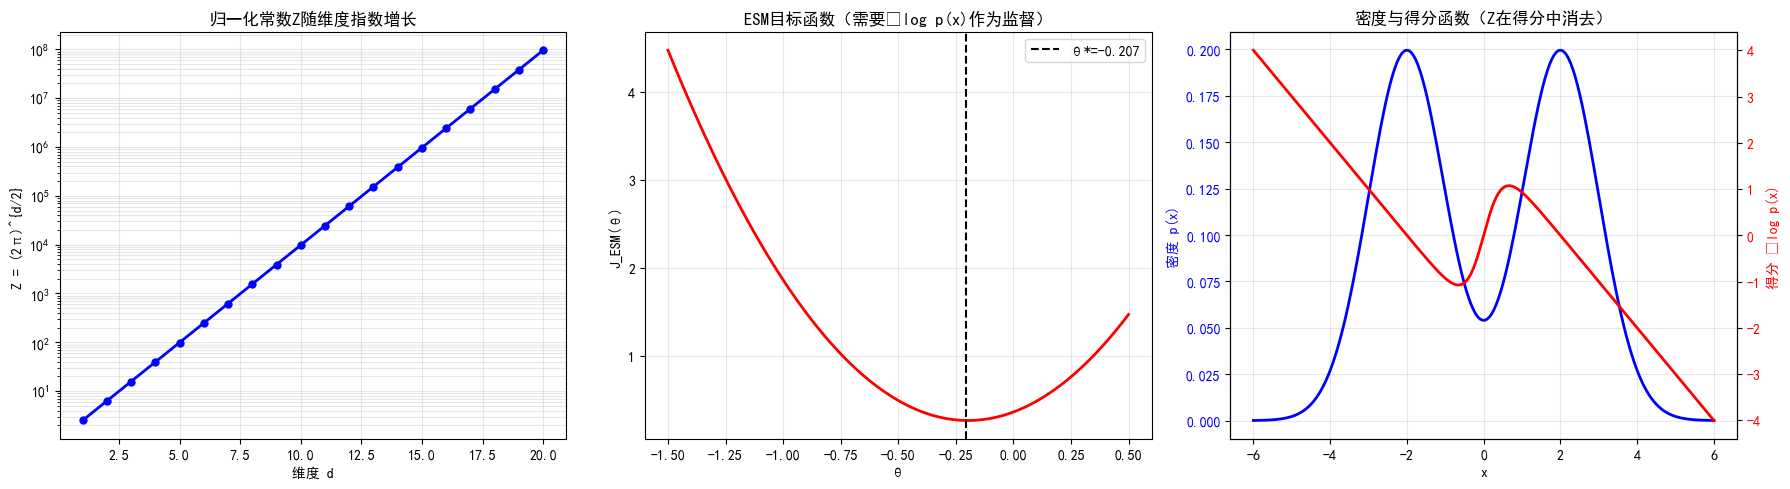


实验6.1 总结
1. 归一化常数Z的困境：低维可算、高维不可算
   - d=2时数值积分精度良好
   - d=10+时Z指数增长，数值积分不可行
2. ESM需要∇log p(x)作为监督信号，而∇log p(x)恰恰未知
   - 这就是得分匹配要解决的核心问题
3. 得分函数'无需Z'的优势：∇log p(x) = ∇log p̃(x)
   - Z在求导时完全消去
   - 即使Z不可计算，得分函数仍可学习


In [1]:
"""
实验6.1 归一化常数困境与得分匹配动机
对应章节：6.1（为什么需要学习得分？）、6.2（ESM与ISM）
素材来源：原创设计，基于6.1节"归一化常数Z的不可解性"和6.2节"ESM失败、ISM瓶颈"

实验内容：
  步骤1：归一化常数Z在高维不可算的数值演示
  步骤2：ESM目标函数在已知分布上的验证（说明需要∇log p(x)作为监督）
  步骤3：得分函数"无需Z"的优势演示

运行前提：纯NumPy/Matplotlib，无需GPU
"""

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN',
            'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)

# 脚本所在目录（用于输出文件路径）
_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()


# ============================================================
# 步骤1：归一化常数Z在高维不可算的数值演示
# ★ 原创设计：直观展示高斯混合分布的Z在低维可解析计算，高维时数值积分失败
# ============================================================
print("=" * 60)
print("步骤1：归一化常数Z在高维不可算的数值演示")
print("=" * 60)

from scipy import integrate

# 2D高斯混合分布的归一化常数Z
def gaussian_mixture_2d_unnorm(x, y):
    """未归一化的2D高斯混合密度"""
    mu1, mu2 = np.array([-2, -2]), np.array([2, 2])
    Sigma1_inv = np.linalg.inv(np.array([[1, 0.3], [0.3, 1]]))
    Sigma2_inv = np.linalg.inv(np.array([[1, -0.3], [-0.3, 1]]))
    det1, det2 = 1 - 0.09, 1 - 0.09

    p1 = np.exp(-0.5 * np.array([x - mu1[0], y - mu1[1]]) @ Sigma1_inv @ np.array([x - mu1[0], y - mu1[1]]))
    p2 = np.exp(-0.5 * np.array([x - mu2[0], y - mu2[1]]) @ Sigma2_inv @ np.array([x - mu2[0], y - mu2[1]]))

    return 0.5 * p1 / (2 * np.pi * np.sqrt(det1)) + 0.5 * p2 / (2 * np.pi * np.sqrt(det2))

# 2D: 数值积分计算Z
Z_2d, err_2d = integrate.dblquad(gaussian_mixture_2d_unnorm, -10, 10, -10, 10)
print(f"2D高斯混合: Z (数值积分) = {Z_2d:.6f}, 误差 = {err_2d:.2e}")
print(f"  理论值: Z = 1.0 (已归一化), 数值积分精度良好")

# 高维情况: 纯高斯分布，维度从1到20
print("\n高维标准高斯 N(0,I) 的归一化常数Z:")
print("  理论值: Z = (2π)^(d/2)")
for d in [1, 2, 5, 10, 20]:
    Z_theory = (2 * np.pi) ** (d / 2)
    # 蒙特卡罗估计
    N_samples = 100000
    samples = np.random.randn(N_samples, d)
    # 用重要性采样估计Z：积分 exp(-||x||^2/2) dx
    # 这里直接展示理论值和对数Z的量级
    log_Z = d / 2 * np.log(2 * np.pi)
    print(f"  d={d:2d}: Z = {Z_theory:.4e}, log(Z) = {log_Z:.2f}")

print("\n关键观察：")
print("  - 低维(d=1,2): Z可直接数值积分")
print("  - 高维(d=10+): Z呈指数增长，数值积分需要2^d量级的网格点，不可行")
print("  - 但得分函数∇log p(x) = -x 与Z无关！Z在求导时消去")


# ============================================================
# 步骤2：ESM目标函数在已知分布上的验证
# ★ 原创设计：在1D高斯混合上展示ESM需要知道∇log p(x)作为监督信号
# ============================================================
print("\n" + "=" * 60)
print("步骤2：ESM目标函数的验证——需要∇log p(x)作为监督")
print("=" * 60)

# 1D高斯混合 p(x) = 0.5*N(-2,1) + 0.5*N(2,1)
def gm_pdf(x):
    return 0.5 * np.exp(-0.5 * (x + 2)**2) / np.sqrt(2*np.pi) + \
           0.5 * np.exp(-0.5 * (x - 2)**2) / np.sqrt(2*np.pi)

def gm_score(x):
    """精确得分函数 ∇log p(x)"""
    p1 = np.exp(-0.5 * (x + 2)**2) / np.sqrt(2*np.pi)
    p2 = np.exp(-0.5 * (x - 2)**2) / np.sqrt(2*np.pi)
    p = 0.5 * p1 + 0.5 * p2
    # ∇log p = (0.5*∇p1 + 0.5*∇p2) / (0.5*p1 + 0.5*p2)
    grad_p1 = -(x + 2) * p1
    grad_p2 = -(x - 2) * p2
    return (0.5 * grad_p1 + 0.5 * grad_p2) / p

# ESM目标：J_ESM(θ) = 0.5 * E_p(x)[||s_θ(x) - ∇log p(x)||^2]
# 这里用一个简单的参数化模型 s_θ(x) = θ*x （线性模型）
x_grid = np.linspace(-6, 6, 200)
true_score = gm_score(x_grid)

# 测试不同θ的ESM损失
N_samples = 50000
x_samples = np.concatenate([np.random.randn(N_samples//2) - 2, np.random.randn(N_samples//2) + 2])

def esm_loss(theta):
    """线性模型 s_θ(x) = θ*x 的ESM损失"""
    s_theta = theta * x_samples
    true_s = gm_score(x_samples)
    return 0.5 * np.mean((s_theta - true_s)**2)

thetas = np.linspace(-1.5, 0.5, 100)
esm_losses = [esm_loss(t) for t in thetas]
best_theta = thetas[np.argmin(esm_losses)]

print(f"线性模型 s_θ(x) = θ*x 的ESM最优解: θ* = {best_theta:.4f}")
print(f"对应ESM损失: {min(esm_losses):.4f}")
print("注意：ESM需要知道∇log p(x)才能计算损失！")
print("  在真实问题中，∇log p(x)不可得——这正是得分匹配要解决的核心问题")


# ============================================================
# 步骤3：得分函数"无需Z"的优势演示
# ★ 原创设计：展示∇log p(x) = ∇log p̃(x)，Z自动消去
# ============================================================
print("\n" + "=" * 60)
print("步骤3：得分函数'无需Z'的优势演示")
print("=" * 60)

# 对比：p(x) = (1/Z)exp(-R(x)) vs p̃(x) = exp(-R(x))
# 其中 R(x) = x^2/2 (标准高斯)
Z = np.sqrt(2 * np.pi)  # 归一化常数

x_test = np.array([-2, -1, 0, 1, 2])

# 归一化密度下的得分
score_normalized = -x_test  # ∇log p(x) = -x

# 未归一化密度下的得分
score_unnormalized = -x_test  # ∇log p̃(x) = ∇(-x^2/2) = -x

print("得分函数'无需Z'的数值验证:")
print(f"{'x':>5s} | {'∇log p(x)':>12s} | {'∇log p̃(x)':>12s} | {'差异':>12s}")
print("-" * 50)
for i in range(len(x_test)):
    diff = score_normalized[i] - score_unnormalized[i]
    print(f"{x_test[i]:5.1f} | {score_normalized[i]:12.6f} | {score_unnormalized[i]:12.6f} | {diff:12.2e}")

print(f"\n结论：∇log p(x) = ∇log p̃(x)，差异恒为0")
print(f"  归一化常数Z = {Z:.4f} 在求导时完全消去")
print(f"  这意味着：即使Z不可计算，得分函数仍然可学习")


# ============================================================
# 可视化
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1：高维Z的指数增长
dims = np.arange(1, 21)
log_Z = dims / 2 * np.log(2 * np.pi)
axes[0].semilogy(dims, np.exp(log_Z), 'bo-', lw=2, markersize=5)
axes[0].set_xlabel('维度 d')
axes[0].set_ylabel('Z = (2π)^{d/2}')
axes[0].set_title('归一化常数Z随维度指数增长')
axes[0].grid(alpha=0.3, which='both')

# 子图2：ESM损失曲线
axes[1].plot(thetas, esm_losses, 'r-', lw=2)
axes[1].axvline(x=best_theta, color='k', linestyle='--', label=f'θ*={best_theta:.3f}')
axes[1].set_xlabel('θ')
axes[1].set_ylabel('J_ESM(θ)')
axes[1].set_title('ESM目标函数（需要∇log p(x)作为监督）')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 子图3：得分函数 vs 密度
axes[2].plot(x_grid, gm_pdf(x_grid), 'b-', lw=2, label='p(x)')
ax2 = axes[2].twinx()
ax2.plot(x_grid, true_score, 'r-', lw=2, label='∇log p(x)')
ax2.set_ylabel('得分 ∇log p(x)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
axes[2].set_xlabel('x')
axes[2].set_ylabel('密度 p(x)', color='blue')
axes[2].tick_params(axis='y', labelcolor='blue')
axes[2].set_title('密度与得分函数（Z在得分中消去）')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤1_Z困境与得分优势.png'), dpi=150)
plt.show()


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验6.1 总结")
print("=" * 60)
print("1. 归一化常数Z的困境：低维可算、高维不可算")
print("   - d=2时数值积分精度良好")
print("   - d=10+时Z指数增长，数值积分不可行")
print("2. ESM需要∇log p(x)作为监督信号，而∇log p(x)恰恰未知")
print("   - 这就是得分匹配要解决的核心问题")
print("3. 得分函数'无需Z'的优势：∇log p(x) = ∇log p̃(x)")
print("   - Z在求导时完全消去")
print("   - 即使Z不可计算，得分函数仍可学习")
